<h1>Análise Exploratória de Dados - Valores de Aluguel em São Paulo</h1>

In [1]:
# 1. abrir arquivo e verificações iniciais
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# definir caminho do arquivo
file_path = '../data/raw/sao-paulo-properties-april-2019.csv'

# ler arquivo
df = pd.read_csv(file_path)

# verificar as primeiras linhas
display(df.head())

# resumo do dataset
print("\n--- Resumo do dataset ---")
df.info()

,Price,Condo,Size,Rooms,Toilets,Suites,Parking,Elevator,Furnished,Swimming Pool,New,District,Negotiation Type,Property Type,Latitude,Longitude
0,930,220,47,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.543138,-46.479486
1,1000,148,45,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.550239,-46.480718
2,1000,100,48,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.542818,-46.485665
3,1000,200,48,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.547171,-46.483014
4,1300,410,55,2,2,1,1,1,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.525025,-46.482436



--- Resumo do dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13640 entries, 0 to 13639
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             13640 non-null  int64  
 1   Condo             13640 non-null  int64  
 2   Size              13640 non-null  int64  
 3   Rooms             13640 non-null  int64  
 4   Toilets           13640 non-null  int64  
 5   Suites            13640 non-null  int64  
 6   Parking           13640 non-null  int64  
 7   Elevator          13640 non-null  int64  
 8   Furnished         13640 non-null  int64  
 9   Swimming Pool     13640 non-null  int64  
 10  New               13640 non-null  int64  
 11  District          13640 non-null  object 
 12  Negotiation Type  13640 non-null  object 
 13  Property Type     13640 non-null  object 
 14  Latitude          13640 non-null  float64
 15  Longitude         13640 non-null  float64
dtypes: float64(2)

In [2]:
# 2. checar valores existentes
# opções de 'Negotiation Type'
print("--- Tipos de Negociação ---")
display(df['Negotiation Type'].value_counts())

# opções de'Property Type'
print("\n--- Tipos de Propriedade ---")
display(df['Property Type'].value_counts())

--- Tipos de Negociação ---


Negotiation Type
rent    7228
sale    6412
Name: count, dtype: int64


--- Tipos de Propriedade ---


Property Type
apartment    13640
Name: count, dtype: int64

<p style="color: red;"><b>Nota:</p></b>Para que o modelo de regressão linear não confunda valores de aluguel ("rent") e venda ("sale"), e gere uma predição equivocada, considerarei apenas os <b>imóveis para aluguel</b>.

In [3]:
# 3. considerar apenas as linhas onde o 'Negotiation Type' é 'rent'
# criar cópia com foco em 'rent'
df_rent = df[df['Negotiation Type'] == 'rent'].copy()

# excluir colunas não necessárias
# aprendi: axis (informa que é para apagar colunas e não linhas)
df_rent = df_rent.drop(['Negotiation Type', 'Property Type'], axis=1)

# checando tamanho atual
print(f"Linhas: {df_rent.shape[0]}. \nColunas: {df_rent.shape[1]}.")

# verificando head
display(df_rent.head())

Linhas: 7228. 
Colunas: 14.


,Price,Condo,Size,Rooms,Toilets,Suites,Parking,Elevator,Furnished,Swimming Pool,New,District,Latitude,Longitude
0,930,220,47,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,-23.543138,-46.479486
1,1000,148,45,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,-23.550239,-46.480718
2,1000,100,48,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,-23.542818,-46.485665
3,1000,200,48,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,-23.547171,-46.483014
4,1300,410,55,2,2,1,1,1,0,0,0,Artur Alvim/São Paulo,-23.525025,-46.482436


<h2>ANÁLISE DA VARIÁVEL: Preço</h2>

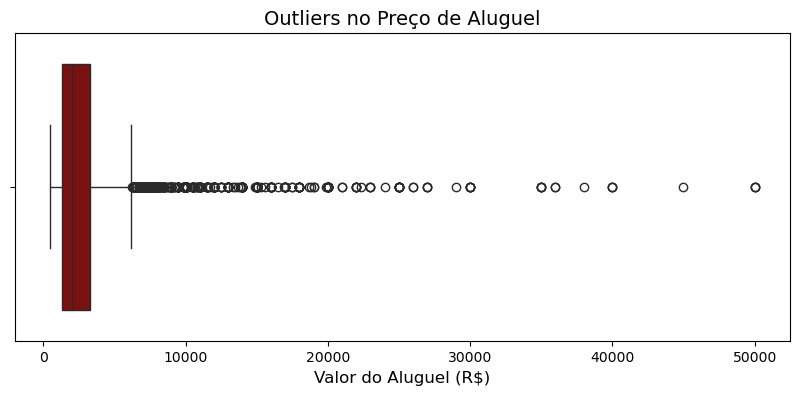

In [4]:
# 4. checar outliers com um boxplot
# alterar tamanho da imagem
plt.figure(figsize=(10, 4))

# criar o boxplot da coluna 'Price'
# aprendi: orient='h' (deixa na horizontal)
sns.boxplot(x=df_rent['Price'], orient='h', color='darkred')

# adicionar título e labels
plt.title('Outliers no Preço de Aluguel', fontsize=14)
plt.xlabel('Valor do Aluguel (R$)', fontsize=12)

# mostrar gráfico
plt.show()

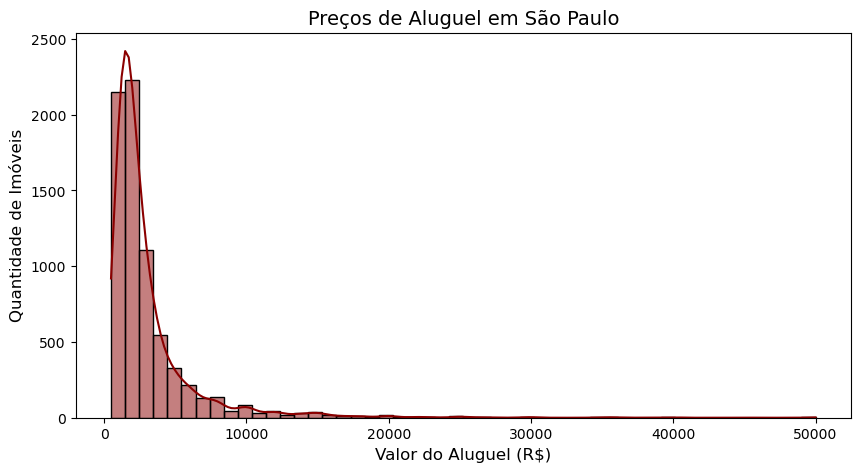


--- Estatísticas dos Preços de Aluguel ---


count     7228.000000
mean      3077.669065
std       3522.830284
min        480.000000
25%       1350.000000
50%       2000.000000
75%       3300.000000
max      50000.000000
Name: Price, dtype: float64

In [5]:
# 5. criar histograma para análise de estatísticas
# alterar tamanho da imagem
plt.figure(figsize=(10, 5))

# criar histograma da coluna 'Price'
# aprendi: kde=True (adiciona uma linha de tendência por cima das barras)
sns.histplot(df_rent['Price'], bins=50, kde=True, color='darkred')

# adicionar título e labels
plt.title('Preços de Aluguel em São Paulo', fontsize=14)
plt.xlabel('Valor do Aluguel (R$)', fontsize=12)
plt.ylabel('Quantidade de Imóveis', fontsize=12)

# mostrar gráfico
plt.show()

# mostrar estatísticas dos preços
print("\n--- Estatísticas dos Preços de Aluguel ---")
display(df_rent['Price'].describe())

<p style="color: red;"><b>Nota:</p></b>Os gráficos mostram que existem outliers extremos, o que atrapalharia a predição de valores. Por isso, aplicarei um filtro para aluguéis de até <b>R$ 15.000</b>.

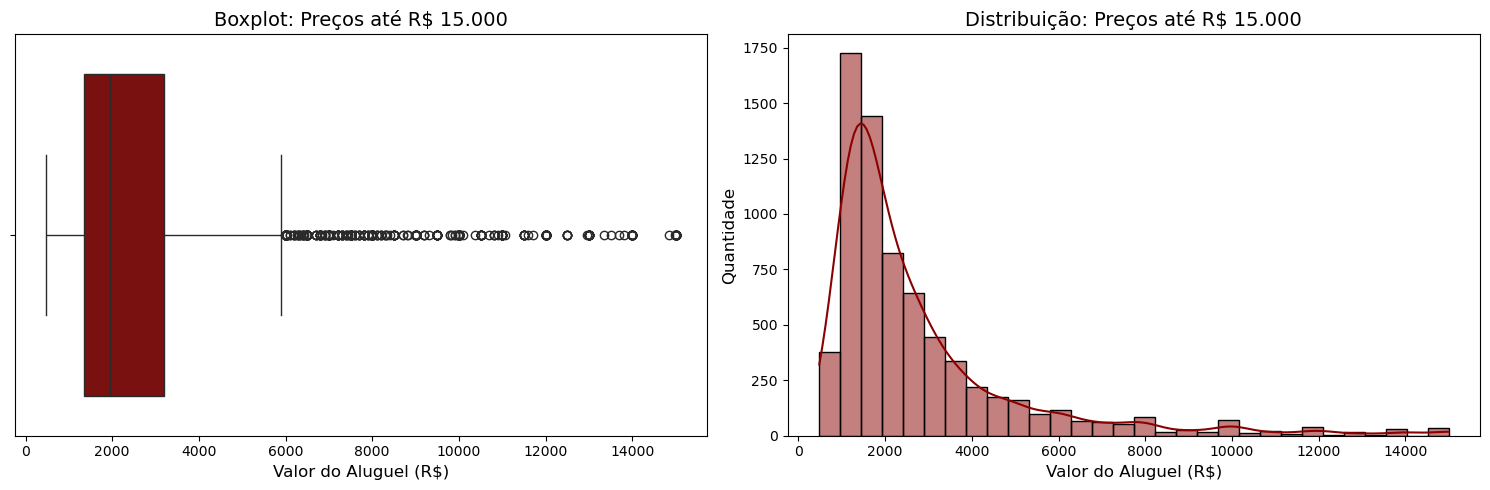

In [6]:
# 6. criar e mostrar gráficos lado a lado
# criar dataframe com o filtro de valores acima de R$ 15.000
df_rent_clean = df_rent[df_rent['Price'] <= 15000].copy()

# criar 2 subplots 
# aprendi: plt.subplots [cria uma 'moldura' com uma grade de eixos (axes). 1, 2 significa 1 linha e 2 colunas]
fig, eixos = plt.subplots(1, 2, figsize=(15, 5))

# desenhar o boxplot primeiro (eixos[0])
sns.boxplot(x=df_rent_clean['Price'], color='darkred', orient='h', ax=eixos[0])
eixos[0].set_title('Boxplot: Preços até R$ 15.000', fontsize=14)
eixos[0].set_xlabel('Valor do Aluguel (R$)', fontsize=12)

# desenhar o histograma após o boxplot (eixos[1])
sns.histplot(df_rent_clean['Price'], bins=30, kde=True, color='darkred', ax=eixos[1])
eixos[1].set_title('Distribuição: Preços até R$ 15.000', fontsize=14)
eixos[1].set_xlabel('Valor do Aluguel (R$)', fontsize=12)
eixos[1].set_ylabel('Quantidade', fontsize=12)

# aprendi: plt.tight_layout (faz o Python calcular automaticamente as margens para remover sobreposições e tudo fique alinhado)
plt.tight_layout()

# mostrar subplots
plt.show()

<h2>CRUZANDO DADOS: Preço x Bairro</h2>

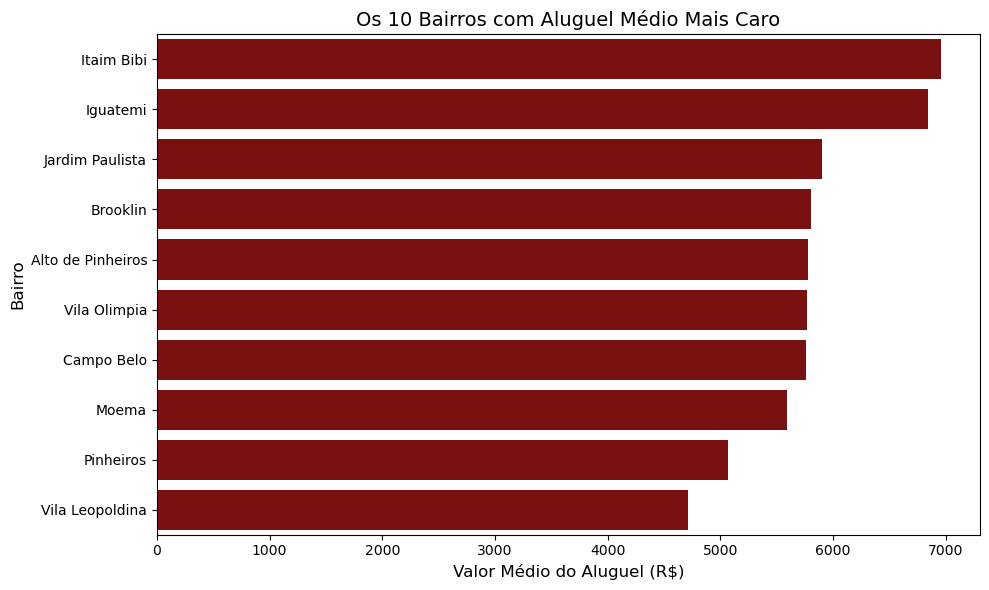

In [9]:
# 7. limpar a coluna 'District'
df_rent_clean['District'] = df_rent_clean['District'].str.replace('/São Paulo', '')

# agrupar os dados por bairro (apenas os 10 mais caros) e calcular a média do preço
top_10_caros = df_rent_clean.groupby('District')['Price'].mean().sort_values(ascending=False).head(10)

# resetar index
top_10_caros = top_10_caros.reset_index()

# gerar um gráfico de barras (horizontais) 
plt.figure(figsize=(10, 6))
sns.barplot(x='Price', y='District', data=top_10_caros, color='darkred')

plt.title('Os 10 Bairros com Aluguel Médio Mais Caro', fontsize=14)
plt.xlabel('Valor Médio do Aluguel (R$)', fontsize=12)
plt.ylabel('Bairro', fontsize=12)

plt.tight_layout()
plt.show()

<p style="color: red;"><b>Nota:</p></b>Primeiro, <b>limpei os nomes dos bairros</b> para que a legibilidade do gráfico ficasse mais simples. Depois, <b>agrupei os dados por bairro</b> e <b>calculei o valor médio do aluguel</b> para analisar a influência da localização do imóvel no preço. <b>Decidi visualizar apenas os 10 bairros mais caros</b> em um gráfico de barras horizontais para facilitar a leitura.

<h2>MATRIZ DE CORRELAÇÃO: O que impacta mais o preço do imóvel?</h2>

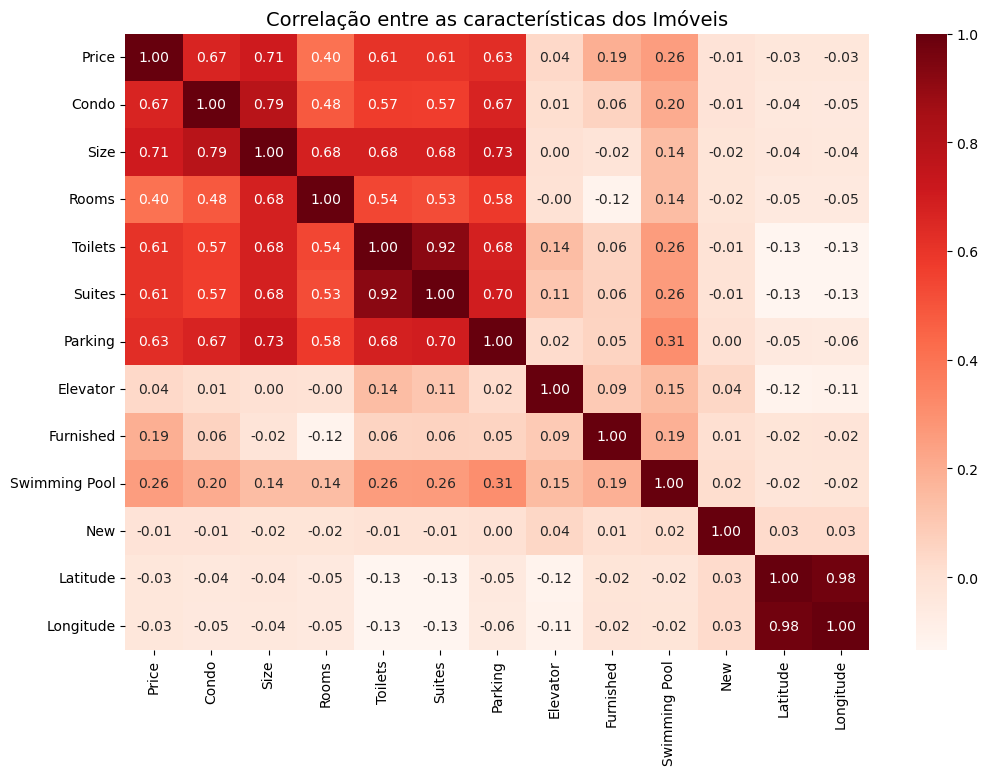

In [8]:
# 8. selecionar apenas colunas de int e float
colunas_num = df_rent_clean.select_dtypes(include=['int64', 'float64'])

# calcular matriz de correlação
corr = colunas_num.corr()

# gerar gráfico de calor (heatmap)
# aprendi: Heatmap
plt.figure(figsize=(12, 8))

# aprendi: annot=True (mostra os números dentro dos quadrados)
# aprendi: cmap='Reds' (usa tons de vermelho para combinar com o resto do projeto)
sns.heatmap(corr, annot=True, fmt=".2f", cmap='Reds')

# mostrar heatmap com a correlação
plt.title('Correlação entre as características dos Imóveis', fontsize=14)
plt.show()

<h2>INSIGHTS </h2>

Com essa análise, percebi que o que <b>mais impacta o preço do aluguel em São Paulo é o tamanho</b>. De forma consistente, quanto maior o apartamento, maior o preço. Além disso, <b>existe uma correlação grande entre o valor do condomínio e o aluguel</b>, o que faz completo sentido, já que prédios com manutenção mais cara costumam ter aluguéis mais altos. A surpresa nessa análise foi a confirmação de que <b>o fator de ter vagas de garagem influencia mais o preço do imóvel do que a quantidade de quartos.</b>

In [12]:
# 9. exportar dados limpos
df_rent_clean.to_csv('../data/processed/rent_clean.csv', index=False)